Завдання 1. Збираємо весь код з попереднього ДЗ в одному місці

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

raw_df = pd.read_csv(r'C:\Users\user\Desktop\python\jup\New folder\train.csv', index_col=0)

train_df, val_df = train_test_split(
    raw_df, 
    test_size=0.2, 
    random_state=67, 
    stratify=raw_df['Exited']
)

In [2]:
# Створюємо трен. і вал. набори
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 
              'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'

train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

In [3]:
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

C:\Users\user\AppData\Local\Temp\ipykernel_20716\1216129695.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [5]:
# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [6]:
from sklearn.linear_model import LogisticRegression

# Створюємо пайплайн, який спочатку запускає препроцесинг, потім тренуємо модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

In [7]:
# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

Area under ROC score on Train dataset: 0.88


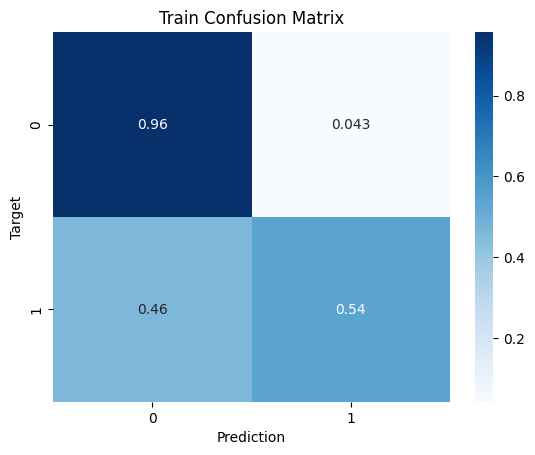

Area under ROC score on Validation dataset: 0.89


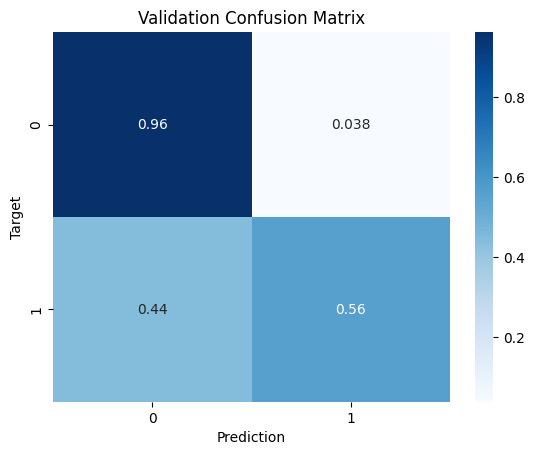

In [9]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

In [10]:
import joblib

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_pipeline.joblib')

['log_reg_pipeline.joblib']

Завдання 2. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

raw_df = pd.read_csv(r'C:\Users\user\Desktop\python\jup\New folder\train.csv', index_col=0)

train_df, val_df = train_test_split(
    raw_df, 
    test_size=0.2, 
    random_state=67, 
    stratify=raw_df['Exited']
)

input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 
              'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'

train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

C:\Users\user\AppData\Local\Temp\ipykernel_20716\2988969205.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()


In [12]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_poly2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [13]:
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

model_pipeline_poly2.fit(train_inputs, train_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

Area under ROC score on Train (poly2) dataset: 0.93


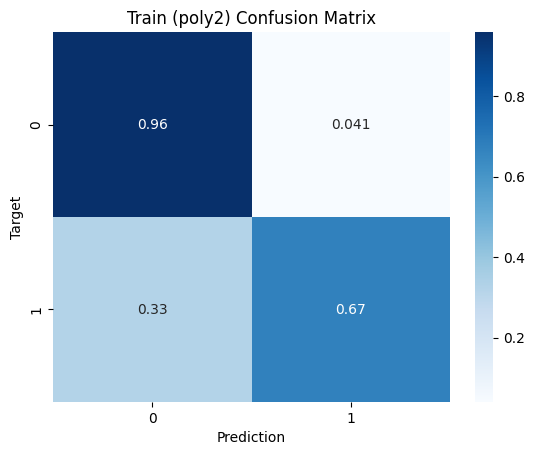

Area under ROC score on Validation (poly2) dataset: 0.93


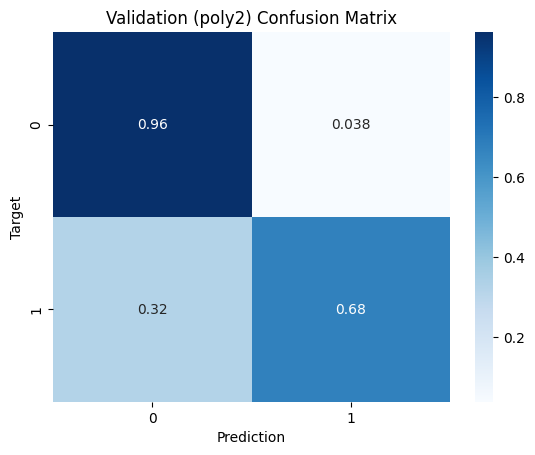

In [15]:
train_preds_poly2 = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train (poly2)')
val_preds_poly2 = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation (poly2)')

Завдання 3. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

In [16]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [17]:
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

model_pipeline_poly4.fit(train_inputs, train_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

Area under ROC score on Train (poly4) dataset: 0.94


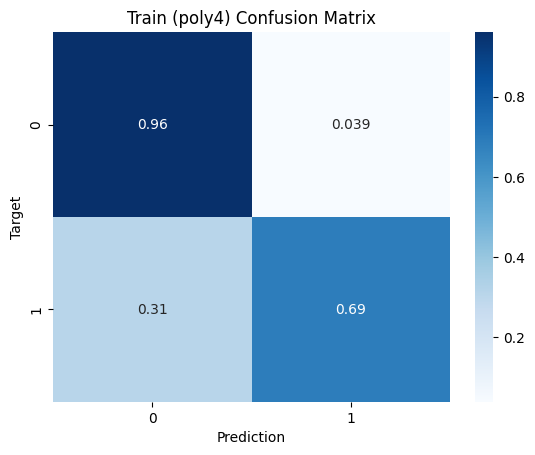

Area under ROC score on Validation (poly4) dataset: 0.93


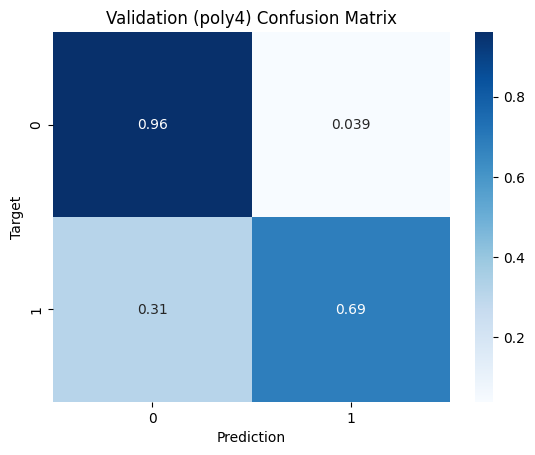

In [18]:
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train (poly4)')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation (poly4)')

Завдання 4. Перенавчання і регуляризація.

Скачайте набір даних regression_data.csv. Звичайте набір даних з regression_data.csv, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені 5 включно.

Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?

In [19]:
data_df = pd.read_csv(r'C:\Users\user\Desktop\python\jup\New folder\regression_data.csv')

data_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [20]:
from sklearn.model_selection import train_test_split

train_data_df, test_data_df = train_test_split(
    data_df,
    test_size=0.2,
    random_state=67
)

print(train_data_df.shape)
print(test_data_df.shape)

(103, 6)
(26, 6)


In [21]:
feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
target_col = 'target'

train_data_inputs = train_data_df[feature_cols].copy()
train_data_targets = train_data_df[target_col].copy()

test_data_inputs = test_data_df[feature_cols].copy()
test_data_targets = test_data_df[target_col].copy()

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('regressor', LinearRegression())
])

regression_pipeline.fit(train_data_inputs, train_data_targets)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['feature_1','feature_2','feature_3','feature_4','feature_5']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [23]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

train_preds = regression_pipeline.predict(train_data_inputs)
test_preds = regression_pipeline.predict(test_data_inputs)

train_rmse = np.sqrt(mean_squared_error(train_data_targets, train_preds))
test_rmse = np.sqrt(mean_squared_error(test_data_targets, test_preds))

train_r2 = r2_score(train_data_targets, train_preds)
test_r2 = r2_score(test_data_targets, test_preds)

print('Train RMSE:', train_rmse, ' | Train R2:', train_r2)
print('Test RMSE:', test_rmse, ' | Test R2:', test_r2)

Train RMSE: 5.324073134780494e-13  | Train R2: 1.0
Test RMSE: 35.314308615997334  | Test R2: 0.4499282003988512


Висновок: Модель перенавчана. Train R2: 1.0, але R² = 0.45, що свідчить що модель пояснює лише 45% розкиду. Модель погано розпізнає закономірність у данних, а підлаштована під тренувальні приклади

Завдання 5. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def build_pipeline(regressor, degree=20):
    return Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', regressor)
    ])

def evaluate_model(pipeline, name):
    pipeline.fit(train_data_inputs, train_data_targets)
    
    train_preds = pipeline.predict(train_data_inputs)
    test_preds = pipeline.predict(test_data_inputs)
    
    train_rmse = np.sqrt(mean_squared_error(train_data_targets, train_preds))
    test_rmse = np.sqrt(mean_squared_error(test_data_targets, test_preds))
    train_r2 = r2_score(train_data_targets, train_preds)
    test_r2 = r2_score(test_data_targets, test_preds)
    
    print(f'--- {name} ---')
    print(f'Train RMSE: {train_rmse:.3f} | Train R2: {train_r2:.3f}')
    print(f'Test RMSE:  {test_rmse:.3f} | Test R2:  {test_r2:.3f}')
    print()
    
    return pipeline

In [25]:
linear_pipeline_20 = build_pipeline(LinearRegression())
linear_pipeline_20 = evaluate_model(linear_pipeline_20, 'LinearRegression (degree=20)')

--- LinearRegression (degree=20) ---
Train RMSE: 24.977 | Train R2: 0.687
Test RMSE:  87871.458 | Test R2:  -3405755.800



In [26]:
ridge_pipeline = build_pipeline(Ridge(alpha=10.0))
ridge_pipeline = evaluate_model(ridge_pipeline, 'Ridge (degree=20)')

lasso_pipeline = build_pipeline(Lasso(alpha=0.1, max_iter=10000))
lasso_pipeline = evaluate_model(lasso_pipeline, 'Lasso (degree=20)')

elastic_pipeline = build_pipeline(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
elastic_pipeline = evaluate_model(elastic_pipeline, 'ElasticNet (degree=20)')

--- Ridge (degree=20) ---
Train RMSE: 17.440 | Train R2: 0.848
Test RMSE:  5251042.521 | Test R2:  -12162113011.639



c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.808841e+02, tolerance: 2.054e+01
  model = cd_fast.enet_coordinate_descent(


--- Lasso (degree=20) ---
Train RMSE: 0.676 | Train R2: 1.000
Test RMSE:  1268.029 | Test R2:  -708.213

--- ElasticNet (degree=20) ---
Train RMSE: 3.423 | Train R2: 0.994
Test RMSE:  1458.361 | Test R2:  -937.098



c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.201528e+03, tolerance: 2.054e+01
  model = cd_fast.enet_coordinate_descent(


In [29]:
lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_
n_total = len(lasso_coefs)
n_zero = np.sum(lasso_coefs == 0)

print(f'Ознак після поліному degree=20: {n_total}')
print(f'З них занулено Lasso: {n_zero}')
print(f'Залишилось "важливих" ознак: {n_total - n_zero}')

Ознак після поліному degree=20: 53129
З них занулено Lasso: 46327
Залишилось "важливих" ознак: 6802


In [30]:
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_
elastic_coefs = elastic_pipeline.named_steps['regressor'].coef_

print('Середній модуль коефіцієнта Ridge:', np.mean(np.abs(ridge_coefs)))
print('Середній модуль коефіцієнта Lasso:', np.mean(np.abs(lasso_coefs)))
print('Середній модуль коефіцієнта ElasticNet:', np.mean(np.abs(elastic_coefs)))

Середній модуль коефіцієнта Ridge: 4.53832270193954e-05
Середній модуль коефіцієнта Lasso: 0.000835721952383482
Середній модуль коефіцієнта ElasticNet: 0.001888523443120294


Висновок: Усі моделі перенавчані, але серед них найкращою виявилась Lasso. Lasso занулив 46237 коефійцієнтів з 53129, зробивши відбір ознак і залишив модель набагато простішою.